In [11]:
import os
import glob
import subprocess
import sys

# =============================================================================
# EDIT THIS BLOCK ONLY
# =============================================================================

CASE_TAG = "tpc_pds"
# Options below are examples:
#   "tpc_only"
#   "tpc_pds"
#   "tpc_pds_pmtpmt"
#   "pds_only_pmtpmt"

CASES = {
    "tpc_only": {
        "data_path": "/home/apaudel/NuGraph/scripts/merged1_July21_40k",
        "run_dir": "/home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_only_ep45_bs64_in8_repo_infeatures",
    },

    "tpc_pds": {
        "data_path": "/home/apaudel/NuGraph/scripts/merged1_July21_40k",
        "run_dir": "/home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures",
    },

    "tpc_pds_pmtpmt": {
        "data_path": "/home/apaudel/NuGraph/scripts/merged1_July21_40k_pmtpmt",
        "run_dir": "/home/apaudel/NuGraph/logs/merged1_July21_40k_pmtpmt_tpc_pds_ep45_bs64_in8_int32",
    },

    "pds_only_pmtpmt": {
        "data_path": "/home/apaudel/NuGraph/scripts/merged1_July21_40k_pmtpmt",
        "run_dir": "/home/apaudel/NuGraph/logs/merged1_July21_40k_pmtpmt_pds_only_ep45_bs64_in8_int32",
    },
}

SCRIPTS_DIR = "/home/apaudel/NuGraph/scripts"
NUGRAPH_LOG = "/home/apaudel/NuGraph/logs"

BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = 0

# Set this to a checkpoint path only if you do not want the latest checkpoint.
CKPT_OVERRIDE = None

# If False and prediction H5 already exists, Cell 1 will not rerun test_event.py.
FORCE_RERUN_TEST = True

# =============================================================================
# Resolve paths
# =============================================================================

os.environ["NUGRAPH_LOG"] = NUGRAPH_LOG

if CASE_TAG not in CASES:
    raise RuntimeError(f"Unknown CASE_TAG={CASE_TAG}. Available: {list(CASES.keys())}")

DATA_PATH = CASES[CASE_TAG]["data_path"]
RUN_DIR = CASES[CASE_TAG]["run_dir"]

if CKPT_OVERRIDE is not None:
    CKPT = CKPT_OVERRIDE
    if not os.path.exists(CKPT):
        raise FileNotFoundError(f"CKPT_OVERRIDE does not exist: {CKPT}")
else:
    ckpts = sorted(
        glob.glob(os.path.join(RUN_DIR, "version_*", "checkpoints", "*.ckpt")),
        key=os.path.getmtime,
    )

    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found under: {RUN_DIR}")

    CKPT = ckpts[-1]

version_dir = os.path.dirname(os.path.dirname(CKPT))
version_name = os.path.basename(version_dir)
run_name = os.path.basename(RUN_DIR.rstrip("/"))

PRED_H5 = os.path.join(
    SCRIPTS_DIR,
    f"{CASE_TAG}_{run_name}_{version_name}_test_predictions.h5",
)

PLOTS_OUTDIR = os.path.join(
    SCRIPTS_DIR,
    f"plots_{CASE_TAG}_{run_name}_{version_name}",
)

os.makedirs(PLOTS_OUTDIR, exist_ok=True)

print("=" * 100)
print("CASE_TAG:")
print(CASE_TAG)
print()
print("Data path:")
print(DATA_PATH)
print()
print("Selected checkpoint:")
print(CKPT)
print()
print("Version directory:")
print(version_dir)
print()
print("Prediction H5 will be:")
print(PRED_H5)
print()
print("Plots output directory will be:")
print(PLOTS_OUTDIR)
print("=" * 100)

# =============================================================================
# Run test_event.py
# =============================================================================

cmd = [
    sys.executable,
    "test_event.py",
    "--device", str(DEVICE),
    "--data-path", DATA_PATH,
    "--checkpoint", CKPT,
    "--outfile", PRED_H5,
    "--batch-size", str(BATCH_SIZE),
    "--num-workers", str(NUM_WORKERS),
]

if os.path.exists(PRED_H5) and not FORCE_RERUN_TEST:
    print("\nPrediction file already exists, skipping test_event.py:")
    print(PRED_H5)
else:
    print("\nRunning command:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        cwd=SCRIPTS_DIR,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    print("\nOutput from test_event.py:")
    print(result.stdout)

    if result.returncode != 0:
        raise RuntimeError(f"test_event.py failed with return code {result.returncode}")

    if not os.path.exists(PRED_H5):
        raise FileNotFoundError(f"Expected output file not found: {PRED_H5}")

print("\nDone.")
print("CASE_TAG =", CASE_TAG)
print("CKPT     =", CKPT)
print("PRED_H5  =", PRED_H5)
print("OUTDIR   =", PLOTS_OUTDIR)

CASE_TAG:
tpc_pds

Data path:
/home/apaudel/NuGraph/scripts/merged1_July21_40k

Selected checkpoint:
/home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures/version_0/checkpoints/epoch=44-step=21105.ckpt

Version directory:
/home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures/version_0

Prediction H5 will be:
/home/apaudel/NuGraph/scripts/tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0_test_predictions.h5

Plots output directory will be:
/home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0

Running command:
/home/apaudel/.conda/envs/nugraph-gpu/bin/python test_event.py --device 0 --data-path /home/apaudel/NuGraph/scripts/merged1_July21_40k --checkpoint /home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures/version_0/checkpoints/epoch=44-step=21105.ckpt --outfile /home/apaudel/NuGraph/scripts/tpc_pds_merged1_July21_4

Case: tpc_pds
Checkpoint: /home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures/version_0/checkpoints/epoch=44-step=21105.ckpt
Prediction file: /home/apaudel/NuGraph/scripts/tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0_test_predictions.h5
Output directory: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0

Important checkpoint hyperparameters:
in_features: 8
hit_features: 128
nexus_features: 32
interaction_features: 32
instance_features: 8
ophit_features: 128
pmt_features: 64
flash_features: 32
event_classes: ['cc_nue', 'es_nue']
event_head: True
semantic_head: False
filter_head: False
use_optical: True
use_optical_only: None
use_pmt_pmt: None
lr: 0.001
learning_rate: None

Checkpoint state check:
  Has optical_net.pmt_to_pmt weights: False

Class ordering from checkpoint:
  0: cc_nue
  1: es_nue

Resolved class indices:
  CC index: 0
  ES index: 1
Saved: /home/apaud

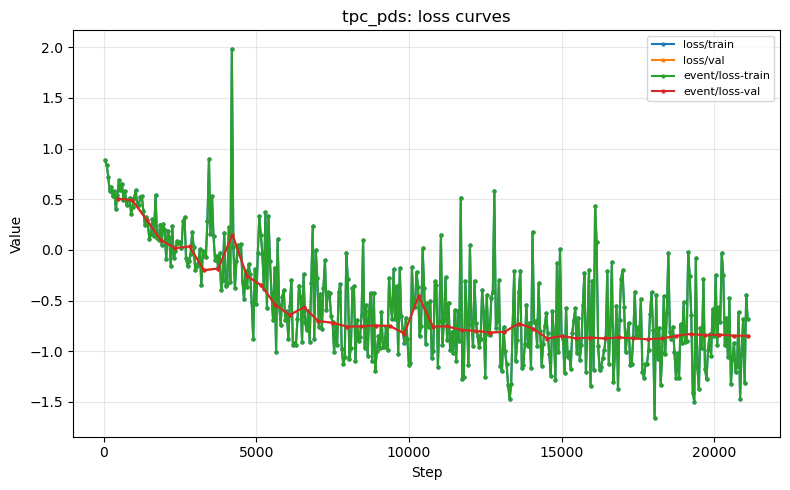

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/loss_curves.png


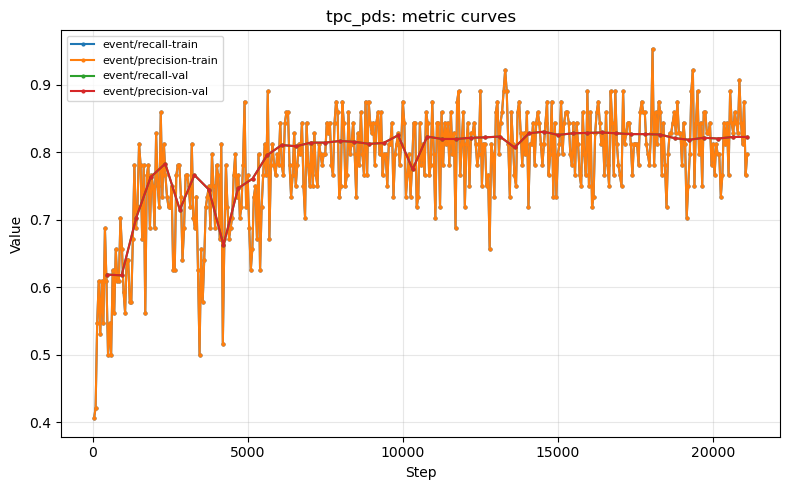

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/metric_curves.png


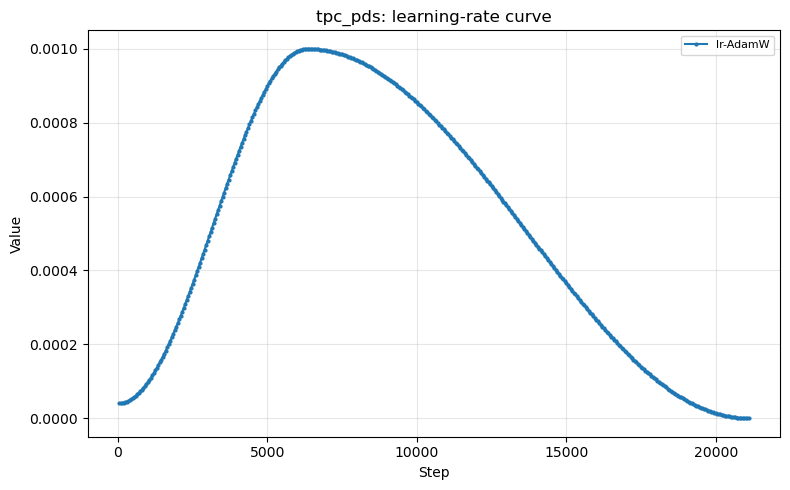

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/learning_rate_curve.png

TensorBoard image tags found:
  event/recall-matrix-val
  event/precision-matrix-val

Displaying latest image for each TensorBoard image tag:

Tag: event/recall-matrix-val
Step: 45
Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/event_recall-matrix-val_latest_step45.png


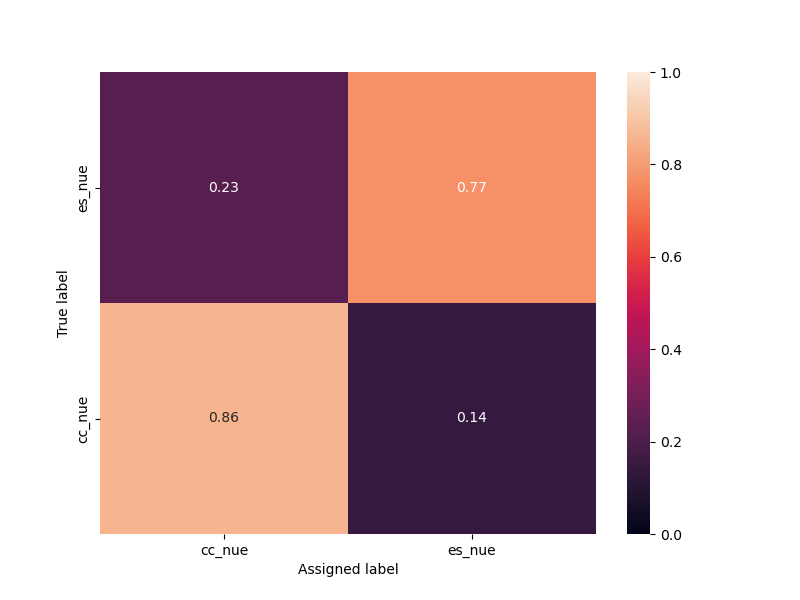


Tag: event/precision-matrix-val
Step: 45
Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/event_precision-matrix-val_latest_step45.png


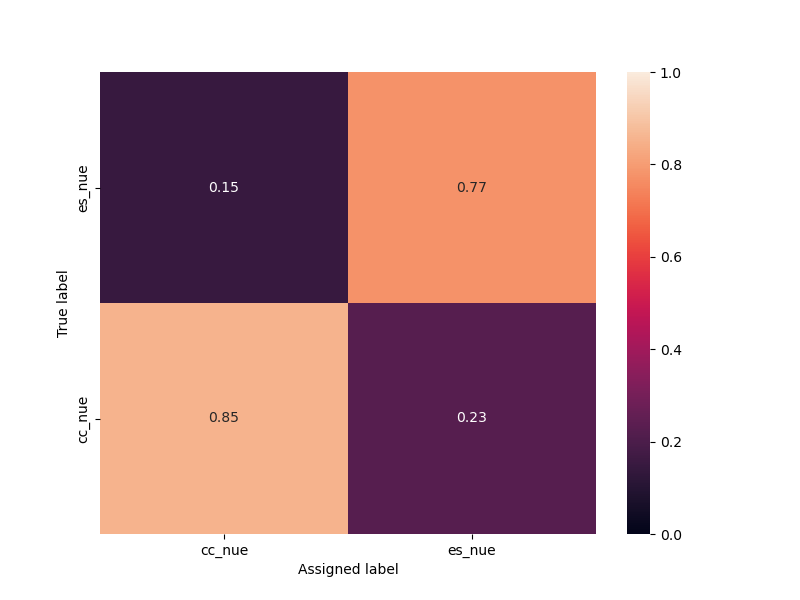


Available HDF keys: ['/events']

Prediction dataframe columns:
['run', 'subrun', 'event', 'y_true', 'y_pred', 'prob_cc_nue', 'prob_es_nue']

First five rows:


,run,subrun,event,y_true,y_pred,prob_cc_nue,prob_es_nue
0,20000216,216,10797,0,0,0.963271,0.036729
1,20000394,394,39686,1,0,0.735823,0.264177
2,20000340,340,36976,1,1,0.217407,0.782593
3,20000071,71,3508,0,0,0.933032,0.066968
4,20000238,238,11873,0,0,0.906747,0.093253



Unique y_true counts:
{np.int64(0): np.int64(980), np.int64(1): np.int64(689)}

Unique y_pred counts:
{np.int64(0): np.int64(981), np.int64(1): np.int64(688)}

Using probability columns:
  P(CC): prob_cc_nue
  P(ES): prob_es_nue

Probability sum check:
  min: 0.9999999180436134
  max: 1.0000000819563866
  mean: 0.9999999981384708

Critical sanity check:
  argmax(probabilities) == y_pred fraction: 1.0000
OK: y_pred matches probability argmax.

Number of test events: 1669
Overall accuracy:       0.7993

Confusion matrix counts:


,Predicted ES,Predicted CC
True CC,167,813
True ES,521,168



Row-normalized confusion matrix:


,Predicted ES,Predicted CC
True CC,0.1704,0.8296
True ES,0.7562,0.2438


Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/confusion_matrix_counts.csv
Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/confusion_matrix_fraction.csv


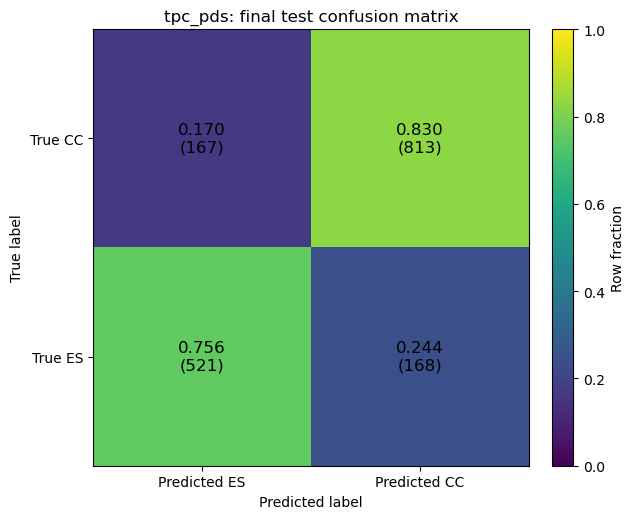

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/final_test_confusion_matrix.png

Average probabilities:


,true_class,average_P_CC,average_P_ES,n_events
0,True CC,0.7244,0.2756,980
1,True ES,0.2762,0.7238,689


Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/average_probabilities.csv


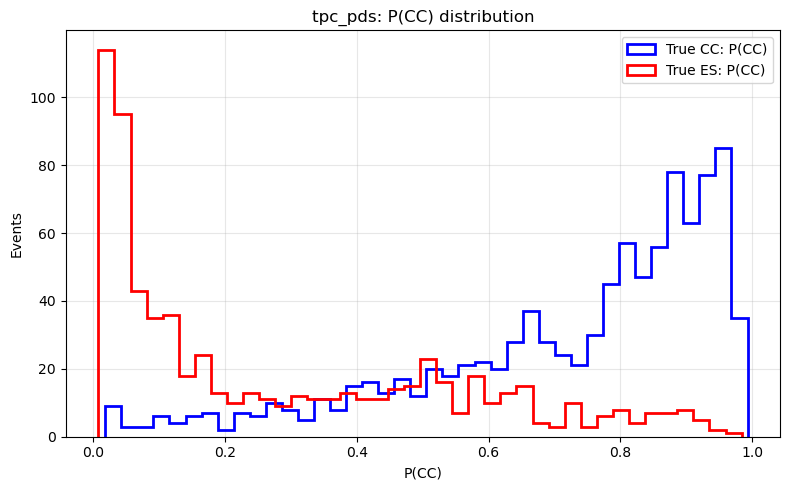

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/pcc_distribution.png


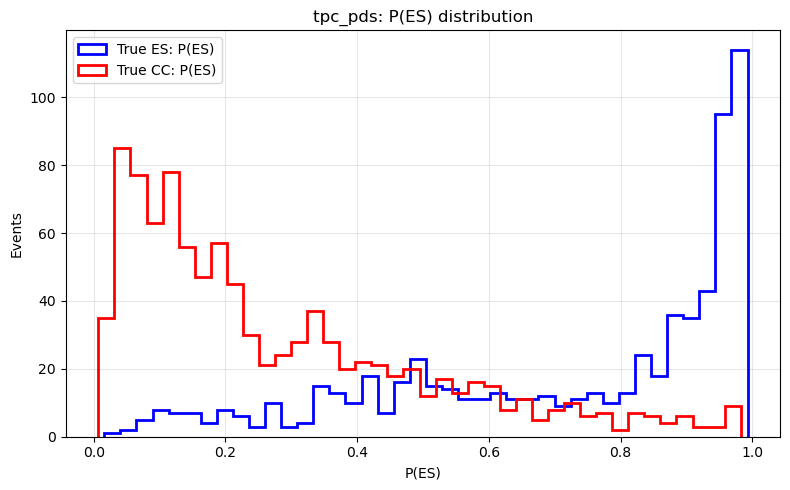

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/pes_distribution.png


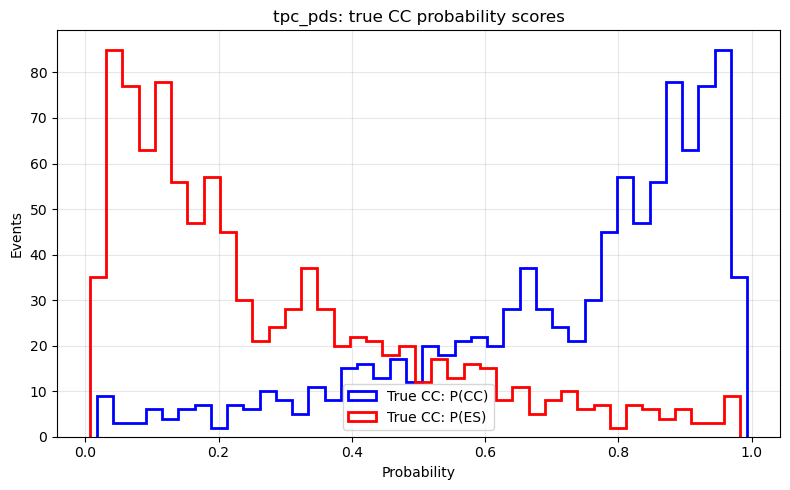

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/true_cc_probability_scores.png


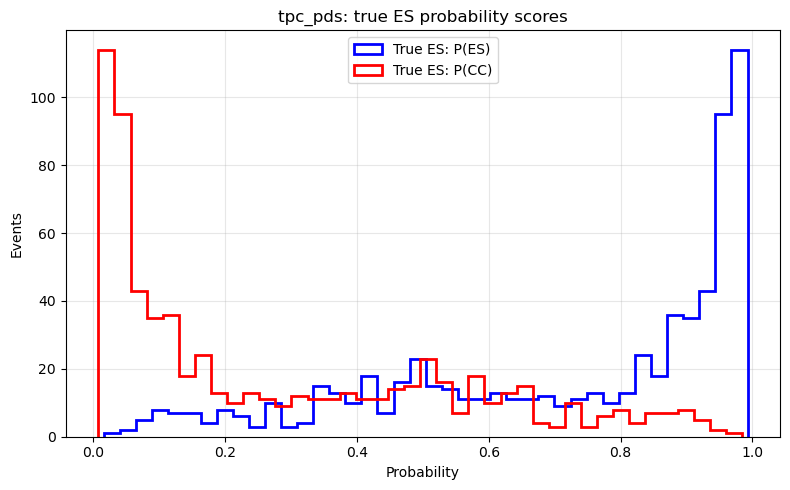

Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/true_es_probability_scores.png
Saved: /home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0/test_predictions_events.csv

Done. Saved all plots/tables in:
/home/apaudel/NuGraph/scripts/plots_tpc_pds_merged1_July21_40k_tpc_pds_ep45_bs64_in8_repo_infeatures_version_0


In [12]:
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# =============================================================================
# Paths from Cell 1
# =============================================================================

required_globals = ["CKPT", "PRED_H5", "PLOTS_OUTDIR"]
for name in required_globals:
    if name not in globals():
        raise RuntimeError(f"Run Cell 1 first. It should define {name}.")

OUTDIR = PLOTS_OUTDIR
os.makedirs(OUTDIR, exist_ok=True)

CASE_LABEL = globals().get("CASE_TAG", "case")

# =============================================================================
# Helper functions
# =============================================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def get_run_dir_from_ckpt(ckpt_path):
    # .../version_1/checkpoints/epoch=...ckpt -> .../version_1
    return os.path.dirname(os.path.dirname(ckpt_path))


def safe_file_name(name):
    return (
        str(name)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("(", "")
        .replace(")", "")
    )


def load_event_accumulator(run_dir):
    event_files = glob.glob(os.path.join(run_dir, "events.out.tfevents.*"))

    if not event_files:
        print("No TensorBoard event files found in:", run_dir)
        return None

    print("\nTensorBoard event files:")
    for f in event_files:
        print(" ", f)

    ea = EventAccumulator(run_dir, size_guidance={"scalars": 0, "images": 0})
    ea.Reload()
    return ea


def scalar_to_df(ea, tag):
    vals = ea.Scalars(tag)
    return pd.DataFrame({
        "step": [v.step for v in vals],
        "value": [v.value for v in vals],
        "wall_time": [v.wall_time for v in vals],
    })


def plot_scalar_group(ea, tags, title, outfile):
    if ea is None:
        return

    available = ea.Tags().get("scalars", [])
    tags = [tag for tag in tags if tag in available]

    if not tags:
        print(f"No scalar tags found for: {title}")
        return

    plt.figure(figsize=(8, 5))

    for tag in tags:
        df_tag = scalar_to_df(ea, tag)
        csv_out = outfile.replace(".png", f"_{safe_file_name(tag)}.csv")
        df_tag.to_csv(csv_out, index=False)
        plt.plot(
            df_tag["step"],
            df_tag["value"],
            marker="o",
            markersize=2,
            linewidth=1.5,
            label=tag,
        )

    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


def save_and_display_tensorboard_images(ea, outdir):
    if ea is None:
        return

    image_tags = ea.Tags().get("images", [])

    if not image_tags:
        print("\nNo TensorBoard image tags found.")
        return

    print("\nTensorBoard image tags found:")
    for tag in image_tags:
        print(" ", tag)

    print("\nDisplaying latest image for each TensorBoard image tag:")

    for tag in image_tags:
        imgs = ea.Images(tag)
        if not imgs:
            continue

        latest = imgs[-1]
        safe_name = safe_file_name(tag)
        outfile = os.path.join(outdir, f"{safe_name}_latest_step{latest.step}.png")

        with open(outfile, "wb") as f:
            f.write(latest.encoded_image_string)

        print(f"\nTag: {tag}")
        print(f"Step: {latest.step}")
        print("Saved:", outfile)
        display(Image(filename=outfile))


def row_normalize(cm_counts):
    row_sums = cm_counts.sum(axis=1, keepdims=True)
    return np.divide(
        cm_counts,
        row_sums,
        out=np.zeros_like(cm_counts, dtype=float),
        where=row_sums != 0,
    )


def plot_confusion_matrix(cm_counts, outfile, title):
    cm_fraction = row_normalize(cm_counts)

    fig, ax = plt.subplots(figsize=(6.6, 5.3))
    im = ax.imshow(cm_fraction, vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted ES", "Predicted CC"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["True CC", "True ES"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm_fraction[i, j]:.3f}\n({cm_counts[i, j]})",
                ha="center",
                va="center",
                fontsize=12,
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row fraction")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


def find_probability_column(df, class_name):
    exact = f"prob_{class_name}"
    if exact in df.columns:
        return exact

    class_lower = str(class_name).lower()
    candidates = [
        col for col in df.columns
        if col.startswith("prob_") and class_lower in col.lower()
    ]

    if len(candidates) == 1:
        return candidates[0]

    raise RuntimeError(
        f"Could not uniquely identify probability column for class {class_name}. "
        f"Candidates: {candidates}. Columns: {df.columns.tolist()}"
    )


# =============================================================================
# 1. Check checkpoint and hyperparameters
# =============================================================================

print("=" * 100)
print("Case:", CASE_LABEL)
print("Checkpoint:", CKPT)
print("Prediction file:", PRED_H5)
print("Output directory:", OUTDIR)
print("=" * 100)

ckpt = safe_torch_load(CKPT)
hyperparameters = ckpt.get("hyper_parameters", {})
state_dict = ckpt.get("state_dict", {})

important_keys = [
    "in_features",
    "hit_features",
    "nexus_features",
    "interaction_features",
    "instance_features",
    "ophit_features",
    "pmt_features",
    "flash_features",
    "event_classes",
    "event_head",
    "semantic_head",
    "filter_head",
    "use_optical",
    "use_optical_only",
    "use_pmt_pmt",
    "lr",
    "learning_rate",
]

print("\nImportant checkpoint hyperparameters:")
for key in important_keys:
    print(f"{key}: {hyperparameters.get(key)}")

has_pmt_pmt_weights = any(
    key.startswith("optical_net.pmt_to_pmt.")
    for key in state_dict
)

print("\nCheckpoint state check:")
print("  Has optical_net.pmt_to_pmt weights:", has_pmt_pmt_weights)

event_classes = list(hyperparameters["event_classes"])

print("\nClass ordering from checkpoint:")
for i, name in enumerate(event_classes):
    print(f"  {i}: {name}")

cc_idx = next(i for i, name in enumerate(event_classes) if "cc" in str(name).lower())
es_idx = next(i for i, name in enumerate(event_classes) if "es" in str(name).lower())

print("\nResolved class indices:")
print("  CC index:", cc_idx)
print("  ES index:", es_idx)

# Save checkpoint summary
summary_txt = os.path.join(OUTDIR, "checkpoint_summary.txt")
with open(summary_txt, "w") as f:
    f.write(f"Case: {CASE_LABEL}\n")
    f.write(f"Checkpoint: {CKPT}\n")
    f.write(f"Prediction file: {PRED_H5}\n")
    f.write(f"Output directory: {OUTDIR}\n")
    f.write(f"Has PMT-to-PMT weights: {has_pmt_pmt_weights}\n\n")
    f.write("Hyperparameters:\n")
    for key in important_keys:
        f.write(f"{key}: {hyperparameters.get(key)}\n")

print("Saved:", summary_txt)


# =============================================================================
# 2. TensorBoard scalar plots and all saved image tags
# =============================================================================

RUN_VERSION_DIR = get_run_dir_from_ckpt(CKPT)
print("\nRun version directory:", RUN_VERSION_DIR)

ea = load_event_accumulator(RUN_VERSION_DIR)

if ea is not None:
    scalar_tags = ea.Tags().get("scalars", [])
    image_tags = ea.Tags().get("images", [])

    print("\nAvailable scalar tags:")
    for tag in scalar_tags:
        print(" ", tag)

    print("\nAvailable image tags:")
    for tag in image_tags:
        print(" ", tag)

    # Loss curves
    loss_tags = [
        "loss/train",
        "loss/val",
        "loss/test",
        "event/loss-train",
        "event/loss-val",
        "event/loss-test",
    ]

    plot_scalar_group(
        ea,
        loss_tags,
        f"{CASE_LABEL}: loss curves",
        os.path.join(OUTDIR, "loss_curves.png"),
    )

    # Usual metrics if present
    metric_keywords = [
        "accuracy",
        "acc",
        "precision",
        "recall",
        "f1",
        "efficiency",
        "auc",
    ]

    metric_tags = [
        tag for tag in scalar_tags
        if any(word in tag.lower() for word in metric_keywords)
    ]

    plot_scalar_group(
        ea,
        metric_tags,
        f"{CASE_LABEL}: metric curves",
        os.path.join(OUTDIR, "metric_curves.png"),
    )

    # Learning rate if present
    lr_tags = [tag for tag in scalar_tags if "lr" in tag.lower()]

    plot_scalar_group(
        ea,
        lr_tags,
        f"{CASE_LABEL}: learning-rate curve",
        os.path.join(OUTDIR, "learning_rate_curve.png"),
    )

    # Display all latest TensorBoard image tags
    save_and_display_tensorboard_images(ea, OUTDIR)


# =============================================================================
# 3. Load test_event.py prediction file
# =============================================================================

with pd.HDFStore(PRED_H5, mode="r") as store:
    print("\nAvailable HDF keys:", store.keys())

df = pd.read_hdf(PRED_H5, key="events")

print("\nPrediction dataframe columns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

y_true = df["y_true"].to_numpy(dtype=int)
y_pred = df["y_pred"].to_numpy(dtype=int)

print("\nUnique y_true counts:")
print(dict(zip(*np.unique(y_true, return_counts=True))))

print("\nUnique y_pred counts:")
print(dict(zip(*np.unique(y_pred, return_counts=True))))


# =============================================================================
# 4. Probability columns and sanity checks
# =============================================================================

cc_probability_column = find_probability_column(df, event_classes[cc_idx])
es_probability_column = find_probability_column(df, event_classes[es_idx])

p_cc = df[cc_probability_column].to_numpy(dtype=float)
p_es = df[es_probability_column].to_numpy(dtype=float)

print("\nUsing probability columns:")
print("  P(CC):", cc_probability_column)
print("  P(ES):", es_probability_column)

prob_matrix = np.zeros((len(df), len(event_classes)))
prob_matrix[:, cc_idx] = p_cc
prob_matrix[:, es_idx] = p_es

prob_sum = prob_matrix.sum(axis=1)
print("\nProbability sum check:")
print("  min:", prob_sum.min())
print("  max:", prob_sum.max())
print("  mean:", prob_sum.mean())

pred_from_prob = np.argmax(prob_matrix, axis=1)
argmax_match = np.mean(pred_from_prob == y_pred)

print("\nCritical sanity check:")
print(f"  argmax(probabilities) == y_pred fraction: {argmax_match:.4f}")

if argmax_match < 0.99:
    print("WARNING: y_pred does not match argmax(probabilities). Check probability mapping.")
else:
    print("OK: y_pred matches probability argmax.")


# =============================================================================
# 5. Final test confusion matrix
# Orientation:
#                  Predicted ES    Predicted CC
# True CC
# True ES
# =============================================================================

cm_counts = np.array([
    [
        np.sum((y_true == cc_idx) & (y_pred == es_idx)),
        np.sum((y_true == cc_idx) & (y_pred == cc_idx)),
    ],
    [
        np.sum((y_true == es_idx) & (y_pred == es_idx)),
        np.sum((y_true == es_idx) & (y_pred == cc_idx)),
    ],
])

cm_fraction = row_normalize(cm_counts)

counts_table = pd.DataFrame(
    cm_counts,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

fraction_table = pd.DataFrame(
    cm_fraction,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

print(f"\nNumber of test events: {len(y_true)}")
print(f"Overall accuracy:       {np.mean(y_true == y_pred):.4f}")

print("\nConfusion matrix counts:")
display(counts_table)

print("\nRow-normalized confusion matrix:")
display(fraction_table.round(4))

counts_csv = os.path.join(OUTDIR, "confusion_matrix_counts.csv")
fraction_csv = os.path.join(OUTDIR, "confusion_matrix_fraction.csv")

counts_table.to_csv(counts_csv)
fraction_table.to_csv(fraction_csv)

print("Saved:", counts_csv)
print("Saved:", fraction_csv)

plot_confusion_matrix(
    cm_counts,
    os.path.join(OUTDIR, "final_test_confusion_matrix.png"),
    f"{CASE_LABEL}: final test confusion matrix",
)


# =============================================================================
# 6. Average probabilities
# =============================================================================

avg_summary = pd.DataFrame([
    {
        "true_class": "True CC",
        "average_P_CC": p_cc[y_true == cc_idx].mean(),
        "average_P_ES": p_es[y_true == cc_idx].mean(),
        "n_events": int(np.sum(y_true == cc_idx)),
    },
    {
        "true_class": "True ES",
        "average_P_CC": p_cc[y_true == es_idx].mean(),
        "average_P_ES": p_es[y_true == es_idx].mean(),
        "n_events": int(np.sum(y_true == es_idx)),
    },
])

print("\nAverage probabilities:")
display(avg_summary.round(4))

avg_csv = os.path.join(OUTDIR, "average_probabilities.csv")
avg_summary.to_csv(avg_csv, index=False)
print("Saved:", avg_csv)


# =============================================================================
# 7. Probability distributions, outline style
# =============================================================================

plt.figure(figsize=(8, 5))
plt.hist(
    p_cc[y_true == cc_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="blue",
    label="True CC: P(CC)",
)
plt.hist(
    p_cc[y_true == es_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="red",
    label="True ES: P(CC)",
)
plt.xlabel("P(CC)")
plt.ylabel("Events")
plt.title(f"{CASE_LABEL}: P(CC) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
pcc_out = os.path.join(OUTDIR, "pcc_distribution.png")
plt.savefig(pcc_out, dpi=200)
plt.show()
print("Saved:", pcc_out)


plt.figure(figsize=(8, 5))
plt.hist(
    p_es[y_true == es_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="blue",
    label="True ES: P(ES)",
)
plt.hist(
    p_es[y_true == cc_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="red",
    label="True CC: P(ES)",
)
plt.xlabel("P(ES)")
plt.ylabel("Events")
plt.title(f"{CASE_LABEL}: P(ES) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
pes_out = os.path.join(OUTDIR, "pes_distribution.png")
plt.savefig(pes_out, dpi=200)
plt.show()
print("Saved:", pes_out)


# Optional: true-class probability overlay
plt.figure(figsize=(8, 5))
plt.hist(
    p_cc[y_true == cc_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="blue",
    label="True CC: P(CC)",
)
plt.hist(
    p_es[y_true == cc_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="red",
    label="True CC: P(ES)",
)
plt.xlabel("Probability")
plt.ylabel("Events")
plt.title(f"{CASE_LABEL}: true CC probability scores")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
true_cc_out = os.path.join(OUTDIR, "true_cc_probability_scores.png")
plt.savefig(true_cc_out, dpi=200)
plt.show()
print("Saved:", true_cc_out)


plt.figure(figsize=(8, 5))
plt.hist(
    p_es[y_true == es_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="blue",
    label="True ES: P(ES)",
)
plt.hist(
    p_cc[y_true == es_idx],
    bins=40,
    histtype="step",
    linewidth=2,
    color="red",
    label="True ES: P(CC)",
)
plt.xlabel("Probability")
plt.ylabel("Events")
plt.title(f"{CASE_LABEL}: true ES probability scores")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
true_es_out = os.path.join(OUTDIR, "true_es_probability_scores.png")
plt.savefig(true_es_out, dpi=200)
plt.show()
print("Saved:", true_es_out)


# =============================================================================
# 8. Save prediction dataframe copy
# =============================================================================

pred_csv = os.path.join(OUTDIR, "test_predictions_events.csv")
df.to_csv(pred_csv, index=False)
print("Saved:", pred_csv)

print("\nDone. Saved all plots/tables in:")
print(OUTDIR)